# Notebook 4 — Alanine Dipeptide MD for VAMPnets Training Data

This notebook runs a **60 ns NVT production** simulation of **alanine dipeptide**
(ACE-ALA-NME) solvated in water at **400 K** using the **AMBER ff14SB** force
field for the peptide and **TIP3P** for water.
Coordinates are saved as a multi-model PDB file every 100 ps, producing
**600 frames** of training data for VAMPnets.

## Why alanine dipeptide?

Alanine dipeptide is the classic benchmark for studying slow conformational
dynamics.  Its two backbone dihedral angles ($\phi$, $\psi$) undergo rare
transitions between metastable states ($C_7^{\text{eq}}$, $C_7^{\text{ax}}$,
$\alpha_R$, etc.) on the nanosecond timescale — ideal for testing
dimensionality reduction and Markov-state models like VAMPnets.

## Why 400 K?

Elevated temperature accelerates barrier crossings between
metastable states, giving richer conformational sampling in the same
wall-clock time.  This makes the training data more informative for
learning the slow dynamics.

## Outline
1. Load the solvated alanine dipeptide PDB
2. Parameterize with AMBER ff14SB (peptide) + TIP3P (water)
3. Energy minimization
4. NPT equilibration (400 K, 1 bar)
5. NVT production (60 ns) — save multi-model PDB every 100 ps
6. Sanity checks: temperature trace and Ramachandran plot

## 0. Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np

import openmm
import openmm.app as app
import openmm.unit as unit

print(f"OpenMM version: {openmm.__version__}")
for i in range(openmm.Platform.getNumPlatforms()):
    print(f"  {openmm.Platform.getPlatform(i).getName()}")

OpenMM version: 8.2
  Reference
  CPU
  CUDA
  OpenCL


## 1. Load the solvated alanine dipeptide

The file `alanine-dipeptide.pdb` contains ACE-ALA-NME (22 atoms) solvated
with 749 water molecules (2269 atoms total).  The PDB does not include
periodic box vectors, so we set them manually based on the coordinate range.

In [2]:
pdb = app.PDBFile("alanine-dipeptide.pdb")
topology = pdb.topology
positions = pdb.positions

print(f"Atoms:    {topology.getNumAtoms()}")
print(f"Residues: {topology.getNumResidues()}")

pos_array = np.array([(p.x, p.y, p.z) for p in positions])  # nm
box_margin = 0.1  # nm padding
box_min = pos_array.min(axis=0) - box_margin
box_max = pos_array.max(axis=0) + box_margin
box_length = box_max - box_min  # nm

vectors = openmm.Vec3(box_length[0], 0, 0), \
          openmm.Vec3(0, box_length[1], 0), \
          openmm.Vec3(0, 0, box_length[2])
topology.setPeriodicBoxVectors(vectors * unit.nanometer)

print(f"Box vectors (nm): {box_length[0]:.3f} x {box_length[1]:.3f} x {box_length[2]:.3f}")

Atoms:    2269
Residues: 752
Box vectors (nm): 3.162 x 3.158 x 3.113


## 2. Parameterize with AMBER ff14SB + TIP3P

Alanine dipeptide (ACE-ALA-NME) consists of standard AMBER residues, so
we use **AMBER ff14SB** for the protein and **TIP3P** for water — both
are built-in OpenMM force field XML files.

In [3]:
forcefield = app.ForceField("amber/ff14SB.xml", "amber/tip3p_standard.xml")

system = forcefield.createSystem(
    topology,
    nonbondedMethod=app.PME,
    nonbondedCutoff=1.0 * unit.nanometer,
    constraints=app.HBonds,
)

print(f"System: {system.getNumParticles()} particles")
print(f"Forces: {system.getNumForces()}")
for i in range(system.getNumForces()):
    print(f"  {system.getForce(i).__class__.__name__}")

System: 2269 particles
Forces: 5
  HarmonicBondForce
  PeriodicTorsionForce
  NonbondedForce
  CMMotionRemover
  HarmonicAngleForce


## 3. Energy minimization

In [4]:
TEMPERATURE = 400.0 * unit.kelvin

integrator = openmm.LangevinMiddleIntegrator(
    TEMPERATURE,
    1.0 / unit.picosecond,
    2.0 * unit.femtosecond,
)

try:
    platform = openmm.Platform.getPlatformByName("CUDA")
    properties = {"Precision": "mixed"}
    print("Using CUDA platform")
except Exception:
    platform = openmm.Platform.getPlatformByName("CPU")
    properties = {}
    print("Using CPU platform")

simulation = app.Simulation(topology, system, integrator, platform, properties)
simulation.context.setPositions(positions)

print("Initial energy:",
      simulation.context.getState(getEnergy=True).getPotentialEnergy())

simulation.minimizeEnergy(maxIterations=5000)

print("After minimization:",
      simulation.context.getState(getEnergy=True).getPotentialEnergy())

Using CUDA platform
Initial energy: -24681.22703373045 kJ/mol
After minimization: -35889.84865343367 kJ/mol


## 4. NPT equilibration (100 ps)

Short NPT run at 400 K and 1 bar to relax the box volume at the
elevated temperature.

In [5]:
PRESSURE = 1.0 * unit.bar
NPT_STEPS = 50_000  # 100 ps at 2 fs/step

barostat = openmm.MonteCarloBarostat(PRESSURE, TEMPERATURE, 25)
system.addForce(barostat)
simulation.context.reinitialize(preserveState=True)

simulation.reporters.append(
    app.StateDataReporter(
        "ala_npt_log.csv", 5000,
        step=True, time=True,
        potentialEnergy=True, temperature=True,
        volume=True, density=True,
    )
)

print(f"Running NPT equilibration for {NPT_STEPS} steps (100 ps) ...")
simulation.step(NPT_STEPS)
print("NPT equilibration complete.")

state = simulation.context.getState(getPositions=True, enforcePeriodicBox=True)
box = state.getPeriodicBoxVectors()
print("Equilibrated box vectors:")
for v in box:
    print(f"  {v}")

Running NPT equilibration for 50000 steps (100 ps) ...
NPT equilibration complete.
Equilibrated box vectors:
  Vec3(x=2.970226856653695, y=0.0, z=0.0) nm
  Vec3(x=0.0, y=2.9662818333161614, z=0.0) nm
  Vec3(x=0.0, y=0.0, z=2.92429551350956) nm


## 5. NVT production (60 ns)

We remove the barostat and run at constant volume.  Coordinates are
saved to a **multi-model PDB file** every 100 ps, yielding **600 frames**
for VAMPnets training.

| Parameter | Value |
|---|---|
| Temperature | 400 K |
| Timestep | 2 fs |
| Total time | 60 ns |
| Total steps | 30,000,000 |
| Save interval | 100 ps (50,000 steps) |
| Frames saved | 600 |

In [6]:
# Remove the barostat for NVT
for i in range(system.getNumForces() - 1, -1, -1):
    if isinstance(system.getForce(i), openmm.MonteCarloBarostat):
        system.removeForce(i)
        break

positions_eq = state.getPositions()

integrator_nvt = openmm.LangevinMiddleIntegrator(
    TEMPERATURE,
    1.0 / unit.picosecond,
    2.0 * unit.femtosecond,
)

simulation_nvt = app.Simulation(topology, system, integrator_nvt, platform, properties)
simulation_nvt.context.setPositions(positions_eq)
simulation_nvt.context.setVelocitiesToTemperature(TEMPERATURE)

NVT_STEPS = 30_000_000     # 60 ns
PDB_INTERVAL = 50_000      # every 100 ps
LOG_INTERVAL = 500_000     # every 1 ns

simulation_nvt.reporters.append(
    app.PDBReporter("vampnet_training_data.pdb", PDB_INTERVAL, enforcePeriodicBox=True)
)
simulation_nvt.reporters.append(
    app.StateDataReporter(
        "ala_nvt_log.csv", LOG_INTERVAL,
        step=True, time=True,
        potentialEnergy=True, temperature=True,
    )
)
simulation_nvt.reporters.append(
    app.StateDataReporter(
        os.devnull, 5_000_000,
        step=True, time=True, speed=True,
        remainingTime=True, totalSteps=NVT_STEPS,
    )
)

print(f"Running NVT production: {NVT_STEPS:,} steps (60 ns)")
print(f"Saving PDB every {PDB_INTERVAL} steps (100 ps) -> 600 frames")
print("This will take a while ...")

simulation_nvt.step(NVT_STEPS)

print("Production complete.")
print(f"Output: vampnet_training_data.pdb ({NVT_STEPS // PDB_INTERVAL} frames)")

Running NVT production: 30,000,000 steps (60 ns)
Saving PDB every 50000 steps (100 ps) -> 600 frames
This will take a while ...
Production complete.
Output: vampnet_training_data.pdb (600 frames)


## 6. Sanity checks

### 6a. Temperature trace

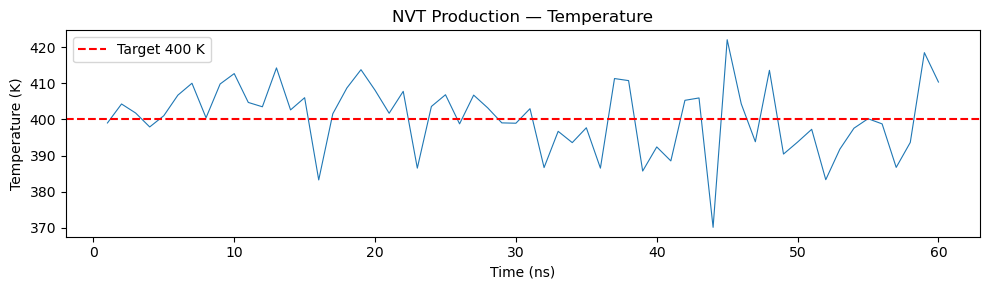

Mean T = 400.58 K
Std  T = 9.66 K


In [7]:
import matplotlib.pyplot as plt

data = np.genfromtxt("ala_nvt_log.csv", delimiter=",", names=True, skip_header=0)

plt.figure(figsize=(10, 3))
plt.plot(data["Time_ps"] / 1000, data["Temperature_K"], lw=0.8)
plt.axhline(400, color="red", ls="--", label="Target 400 K")
plt.xlabel("Time (ns)")
plt.ylabel("Temperature (K)")
plt.title("NVT Production — Temperature")
plt.legend()
plt.tight_layout()
plt.savefig("ala_nvt_temperature.png", dpi=150)
plt.show()

print(f"Mean T = {data['Temperature_K'].mean():.2f} K")
print(f"Std  T = {data['Temperature_K'].std():.2f} K")

### 6b. Ramachandran plot ($\phi$, $\psi$)

We extract the backbone dihedrals from the saved PDB frames using
MDAnalysis to verify that conformational transitions are being sampled.

Loaded 600 frames


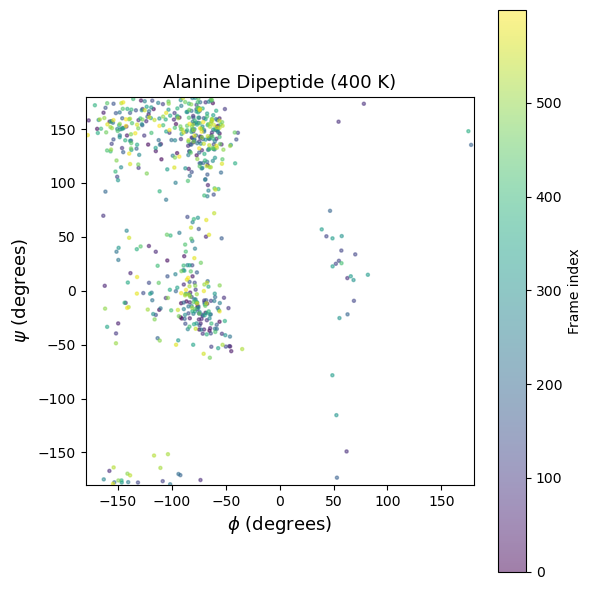

Phi range: -177.9 to 177.6
Psi range: -179.4 to 178.9


In [9]:
import MDAnalysis as mda
from MDAnalysis.analysis.dihedrals import Ramachandran

u = mda.Universe("vampnet_training_data.pdb")
print(f"Loaded {u.trajectory.n_frames} frames")

rama = Ramachandran(u.select_atoms("protein")).run()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(rama.results.angles[:, 0, 0], rama.results.angles[:, 0, 1],
           s=5, alpha=0.5, c=np.arange(len(rama.results.angles)),
           cmap="viridis")
ax.set_xlabel(r"$\phi$ (degrees)", fontsize=13)
ax.set_ylabel(r"$\psi$ (degrees)", fontsize=13)
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_title("Alanine Dipeptide (400 K)", fontsize=13)
ax.set_aspect("equal")
cbar = plt.colorbar(ax.collections[0], ax=ax, label="Frame index")
plt.tight_layout()
plt.savefig("ala_ramachandran.png", dpi=150)
plt.show()

print(f"Phi range: {rama.results.angles[:, 0, 0].min():.1f} to {rama.results.angles[:, 0, 0].max():.1f}")
print(f"Psi range: {rama.results.angles[:, 0, 1].min():.1f} to {rama.results.angles[:, 0, 1].max():.1f}")

## Summary

| File | Description |
|---|---|
| `vampnet_training_data.pdb` | 600-frame multi-model PDB (one frame per 100 ps) |
| `ala_npt_log.csv` | NPT equilibration log |
| `ala_nvt_log.csv` | NVT production log |
| `ala_nvt_temperature.png` | Temperature trace plot |
| `ala_ramachandran.png` | Ramachandran scatter plot |

The file `vampnet_training_data.pdb` is ready to be used as input for
VAMPnets training.